# CA-AOCP: Demonstration on Synthetic Changepoint Data

**Changepoint-Aware Adaptive Online Conformal Prediction**

This notebook demonstrates the CA-AOCP algorithm on a synthetic dataset
with a single mean-shift changepoint at t = 500 (N(0,1) → N(4,1)).

**Contents**
1. Load data and visualise
2. Configure and run CA-AOCP
3. BOCPD posterior heatmap
4. Regime relevance and effective sample size
5. Prediction intervals
6. Comparison with baselines (ACI, ACI-SW, EWMA-CP)
7. Summary metrics table
8. Parameter sensitivity

In [11]:
!git clone https://github.com/cotwint/ca_aocp.git

fatal: destination path 'ca_aocp' already exists and is not an empty directory.


In [15]:
import sys, os
from pathlib import Path
PROJECT_ROOT = os.path.abspath("ca_aocp")   # /content/ca_aocp in the notebook kernel
sys.path.insert(0, PROJECT_ROOT)

# Clear stale namespace/import cache from earlier failed attempts.
for module_name in list(sys.modules):
    if module_name == "ca_aocp" or module_name.startswith("ca_aocp."):
        del sys.modules[module_name]

print('cwd =', Path.cwd())
print('project root =', PROJECT_ROOT)
print('root exists =', os.path.exists(PROJECT_ROOT))
print('nested init exists =', os.path.exists(os.path.join(PROJECT_ROOT, 'ca_aocp', '__init__.py')))
print('sys.path[:3] =', sys.path[:3])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

# ── CA-AOCP modules ──
from ca_aocp import CAAOCP
from ca_aocp.predictors import RollingMeanPredictor, ExponentialSmoothingPredictor
from baselines import ACI, ACISlidingWindow, EWMACP
from utils import (
    plot_data, plot_intervals, plot_rolling_coverage,
    plot_bocpd_posterior, plot_regime_relevance, plot_neff,
    plot_alpha_trajectory, plot_comparison, summary_table,
)

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
print("Imports OK.")

cwd = /content
project root = /content/ca_aocp
root exists = True
nested init exists = True
sys.path[:3] = ['/content/ca_aocp', '/content/ca_aocp', '/content/ca_aocp']
Imports OK.


In [19]:
# ── Load the synthetic dataset ──────────────────────────────────────
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "synthetic_single_cp.csv")
df = pd.read_csv(DATA_PATH)

ys  = df["value"].values      # Y_1, …, Y_T
T   = len(ys)
TAU = 500                     # true changepoint (known for evaluation only)
ALPHA = 0.1                   # nominal miscoverage → target 90% coverage

print(f"T = {T}  |  Changepoint at τ = {TAU}")
print(f"Pre-change  μ ≈ {ys[:TAU].mean():.3f}  σ ≈ {ys[:TAU].std():.3f}")
print(f"Post-change μ ≈ {ys[TAU:].mean():.3f}  σ ≈ {ys[TAU:].std():.3f}")

T = 1000  |  Changepoint at τ = 500
Pre-change  μ ≈ 0.011  σ ≈ 0.978
Post-change μ ≈ 4.038  σ ≈ 0.974


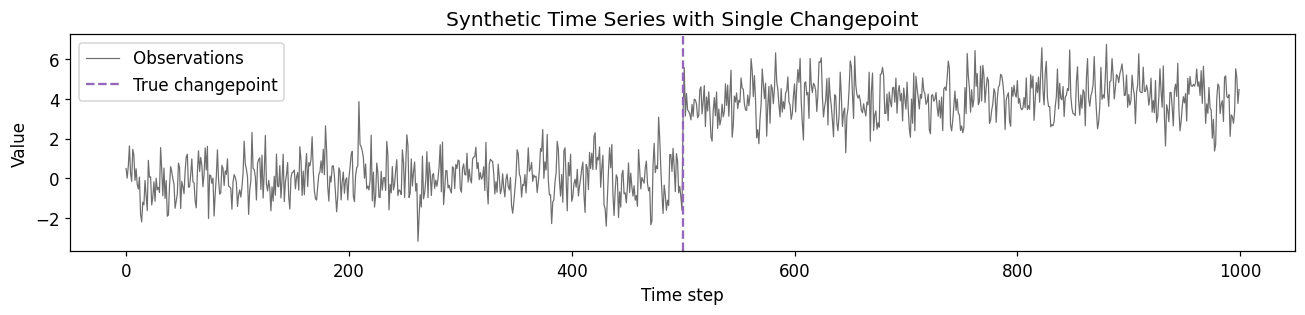

In [21]:
fig = plot_data(ys, tau=TAU)
plt.show()

## 2. Configure and Run CA-AOCP

**Hyperparameter choices** (see Table 2 in the paper):
- `hazard = 0.005` → prior changepoint frequency ≈ 1 per 200 steps
- `decay = 0.01` → gentle within-regime recency downweighting
- `eta = 0.02` → ACI step size
- `temperature = 0.5` → smooth surrogate sharpness
- `RollingMeanPredictor(window=20)` → simple online predictor

In [22]:
# ── Predictor (shared across all methods for fair comparison) ──────
def make_predictor():
    return RollingMeanPredictor(window=20)

# ── CA-AOCP configuration ──────────────────────────────────────────
model = CAAOCP(
    alpha        = ALPHA,
    eta          = 0.02,
    decay        = 0.01,
    temperature  = 0.5,
    hazard       = 0.005,
    bocpd_mu0    = 0.0,
    bocpd_kappa0 = 1.0,
    bocpd_alpha0 = 2.0,    # slightly stronger prior on variance
    bocpd_beta0  = 1.0,
    max_run_length = 400,
    predictor    = make_predictor(),
    init_radius  = 1.0,    # warm-start radius (≈ pre-change std)
    true_changepoint = TAU,
)
print("CA-AOCP configured.")

CA-AOCP configured.


In [23]:
# ── Run CA-AOCP step-by-step to collect BOCPD posteriors ──────────
from ca_aocp.bocpd import GaussianBOCPD

results_caaocp = model.run(ys)

# Collect BOCPD run-length posteriors at every step for the heatmap.
# We rerun BOCPD standalone (same parameters) to capture all posteriors.
bocpd_diag = GaussianBOCPD(
    hazard=0.005, mu0=0.0, kappa0=1.0, alpha0=2.0, beta0=1.0,
    max_run_length=400,
)
posteriors = []
# Use the conformity scores stored in the results
scores = results_caaocp.scores
for s in scores:
    posteriors.append(bocpd_diag.get_run_length_posterior().copy())
    bocpd_diag.update(s)

print(f"Long-run coverage : {results_caaocp.long_run_coverage():.3f}  "
      f"(target {1 - ALPHA:.1f})")
print(f"Mean interval width: {(results_caaocp.upper_bounds - results_caaocp.lower_bounds).mean():.3f}")
print(f"Mean N_eff         : {results_caaocp.neff_sequence.mean():.1f}")

Long-run coverage : 0.933  (target 0.9)
Mean interval width: 3.944
Mean N_eff         : 109.9


## 3. BOCPD Run-Length Posterior

The heatmap shows P(r_t = k | S_{1:t}). Before the changepoint, probability
mass sits on large run lengths (bottom-right region is dark). Immediately
after τ = 500, the posterior resets — mass concentrates near k = 0 — and
the pre-change weights π_{t,i} collapse exponentially.

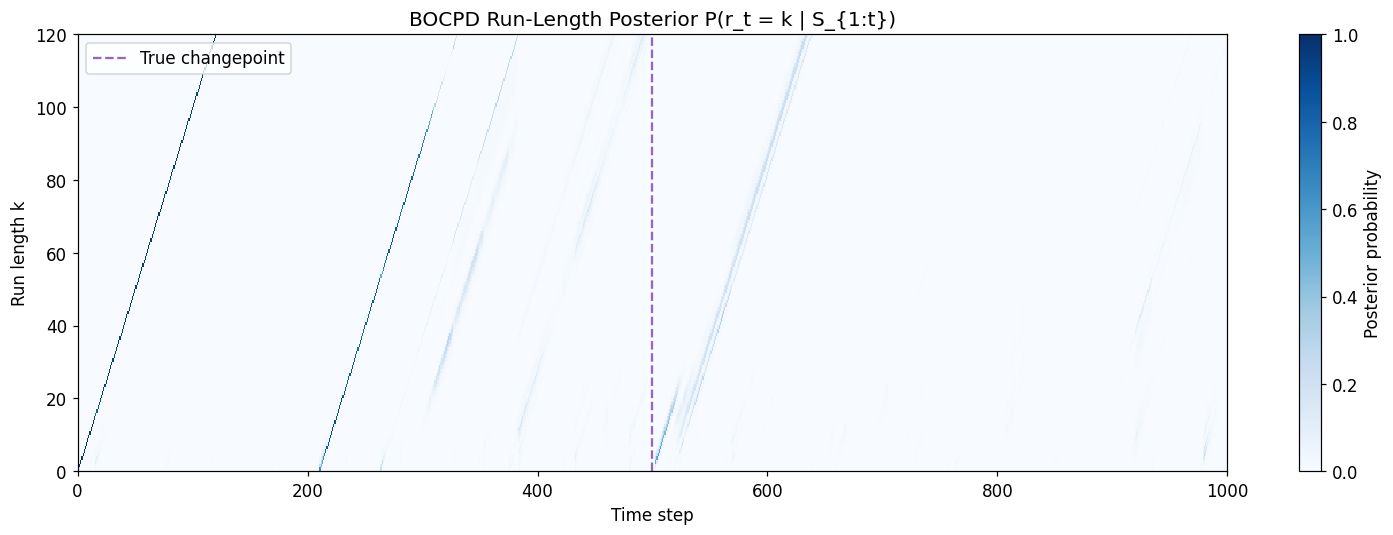

In [24]:
fig = plot_bocpd_posterior(posteriors, tau=TAU, max_rl=120)
plt.show()

## 4. Regime Relevance and Effective Sample Size

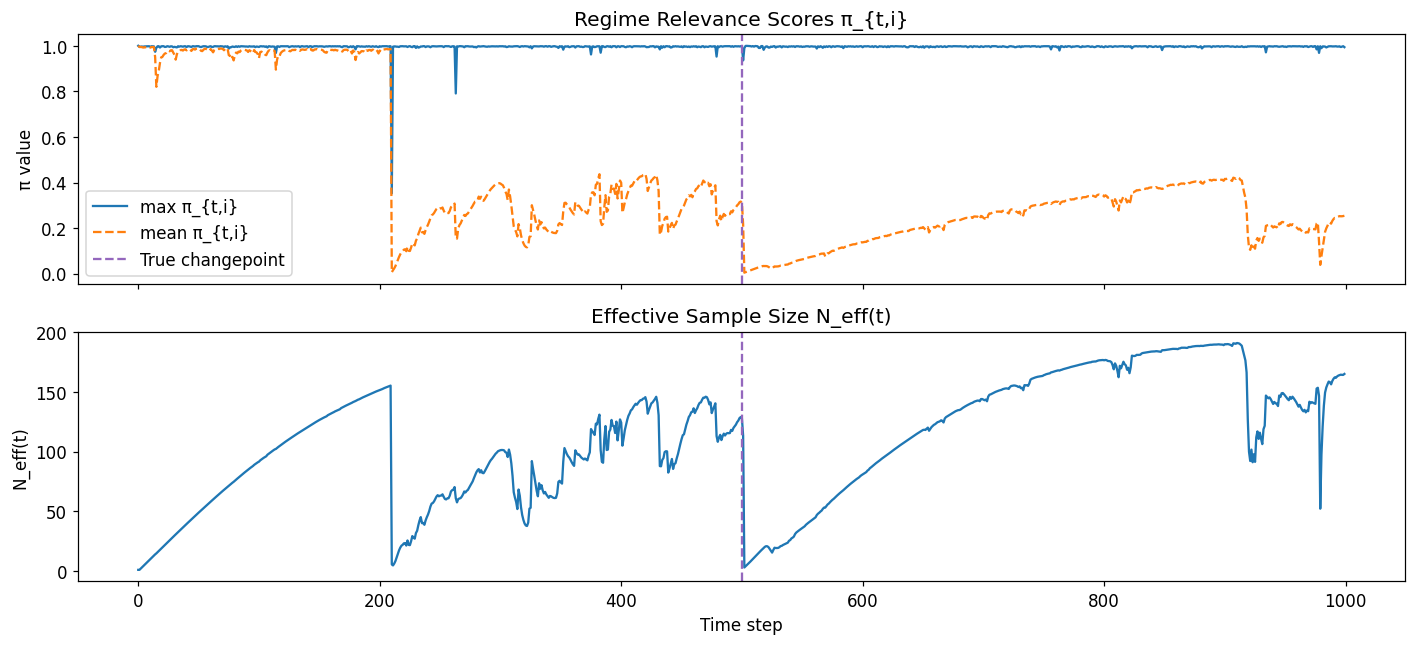

N_eff just before changepoint (t=499): 128.1
N_eff just after  changepoint (t=510): 10.0
N_eff recovered   (t=600):             80.3


In [25]:
pi_list = [step.pi for step in results_caaocp.steps]

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

# ── Max regime relevance score ────────────────────────────────────
pi_max  = [p.max()  if len(p) > 0 else 1.0 for p in pi_list]
pi_mean = [p.mean() if len(p) > 0 else 1.0 for p in pi_list]
axes[0].plot(pi_max,  label="max π_{t,i}",  color="#1f77b4", lw=1.5)
axes[0].plot(pi_mean, label="mean π_{t,i}", color="#ff7f0e", lw=1.5, ls="--")
axes[0].axvline(TAU, color="#9467bd", lw=1.5, ls="--", label="True changepoint")
axes[0].set_ylabel("π value")
axes[0].set_title("Regime Relevance Scores π_{t,i}")
axes[0].legend()

# ── Effective sample size ─────────────────────────────────────────
axes[1].plot(results_caaocp.neff_sequence, color="#1f77b4", lw=1.5)
axes[1].axvline(TAU, color="#9467bd", lw=1.5, ls="--")
axes[1].set_ylabel("N_eff(t)")
axes[1].set_xlabel("Time step")
axes[1].set_title("Effective Sample Size N_eff(t)")

fig.tight_layout()
plt.show()

print(f"N_eff just before changepoint (t=499): "
      f"{results_caaocp.neff_sequence[498]:.1f}")
print(f"N_eff just after  changepoint (t=510): "
      f"{results_caaocp.neff_sequence[509]:.1f}")
print(f"N_eff recovered   (t=600):             "
      f"{results_caaocp.neff_sequence[599]:.1f}")

## 5. Prediction Intervals

The 90% interval ribbon and the raw observations.
Notice how the ribbon expands and re-centres quickly after τ = 500.

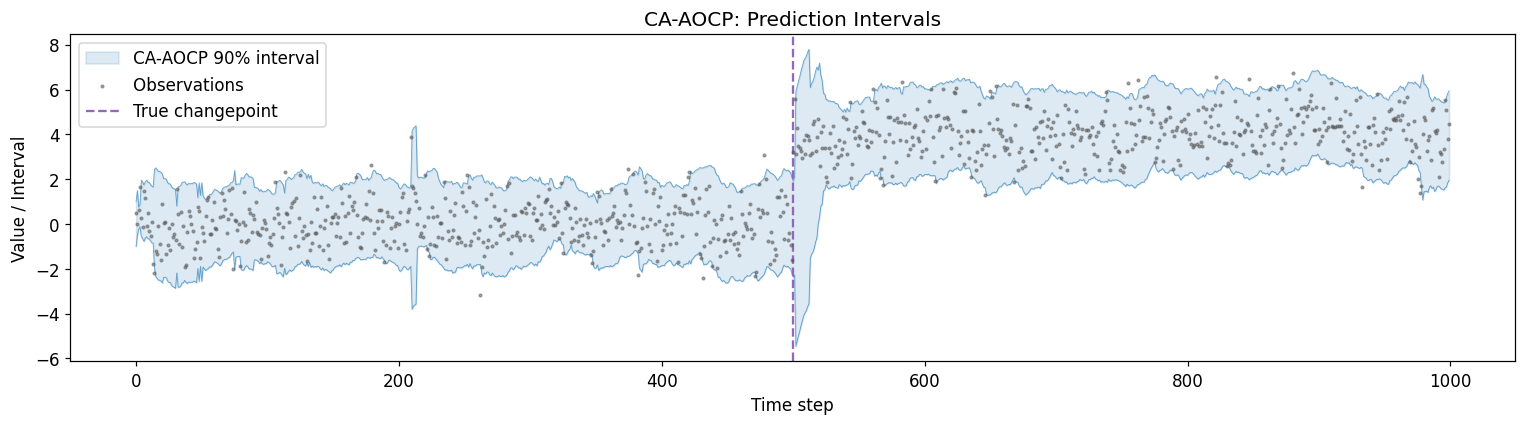

In [26]:
fig = plot_intervals(
    ys,
    results_caaocp.lower_bounds,
    results_caaocp.upper_bounds,
    tau=TAU,
    method_name="CA-AOCP",
    alpha=ALPHA,
)
plt.show()

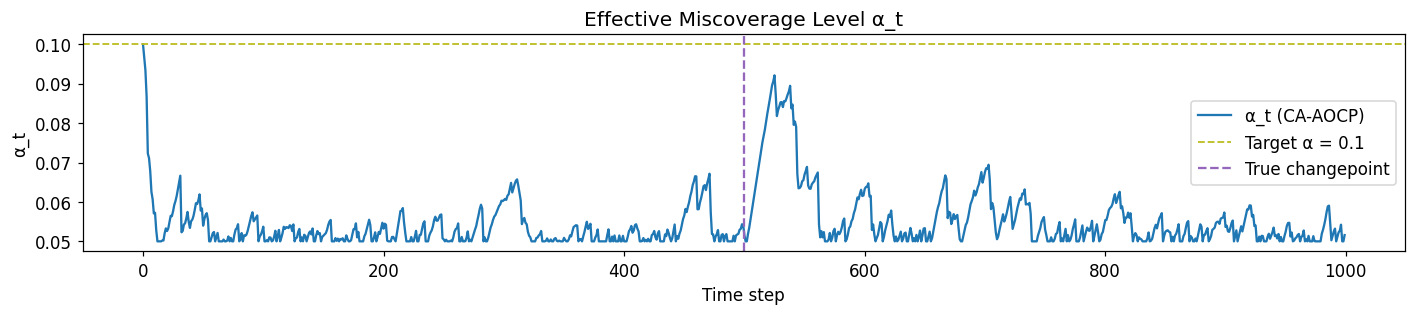

In [10]:
fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(results_caaocp.alpha_sequence, color="#1f77b4", lw=1.5, label="α_t (CA-AOCP)")
ax.axhline(ALPHA, color="#bcbd22", ls="--", lw=1.2, label=f"Target α = {ALPHA}")
ax.axvline(TAU, color="#9467bd", lw=1.5, ls="--", label="True changepoint")
ax.set_xlabel("Time step")
ax.set_ylabel("α_t")
ax.set_title("Effective Miscoverage Level α_t")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Comparison with Baselines

We compare four methods:
- **CA-AOCP** (this work): BOCPD weights + smooth ACI
- **ACI**: standard uniform-weight adaptive conformal inference
- **ACI-SW (W=100)**: ACI with a sliding window of 100 steps
- **EWMA-CP**: exponential decay weights, no changepoint detection

In [28]:
# ── Baselines ──────────────────────────────────────────────────────
aci = ACI(
    alpha=ALPHA, eta=0.02, temperature=0.5,
    predictor=make_predictor(), init_radius=1.0,
).run(ys)

aci_sw = ACISlidingWindow(
    alpha=ALPHA, eta=0.02, temperature=0.5,
    window=100, predictor=make_predictor(), init_radius=1.0,
).run(ys)

ewma_cp = EWMACP(
    alpha=ALPHA, eta=0.02, temperature=0.5, decay=0.01,
    predictor=make_predictor(), init_radius=1.0,
).run(ys)

print("Baselines computed.")

Baselines computed.


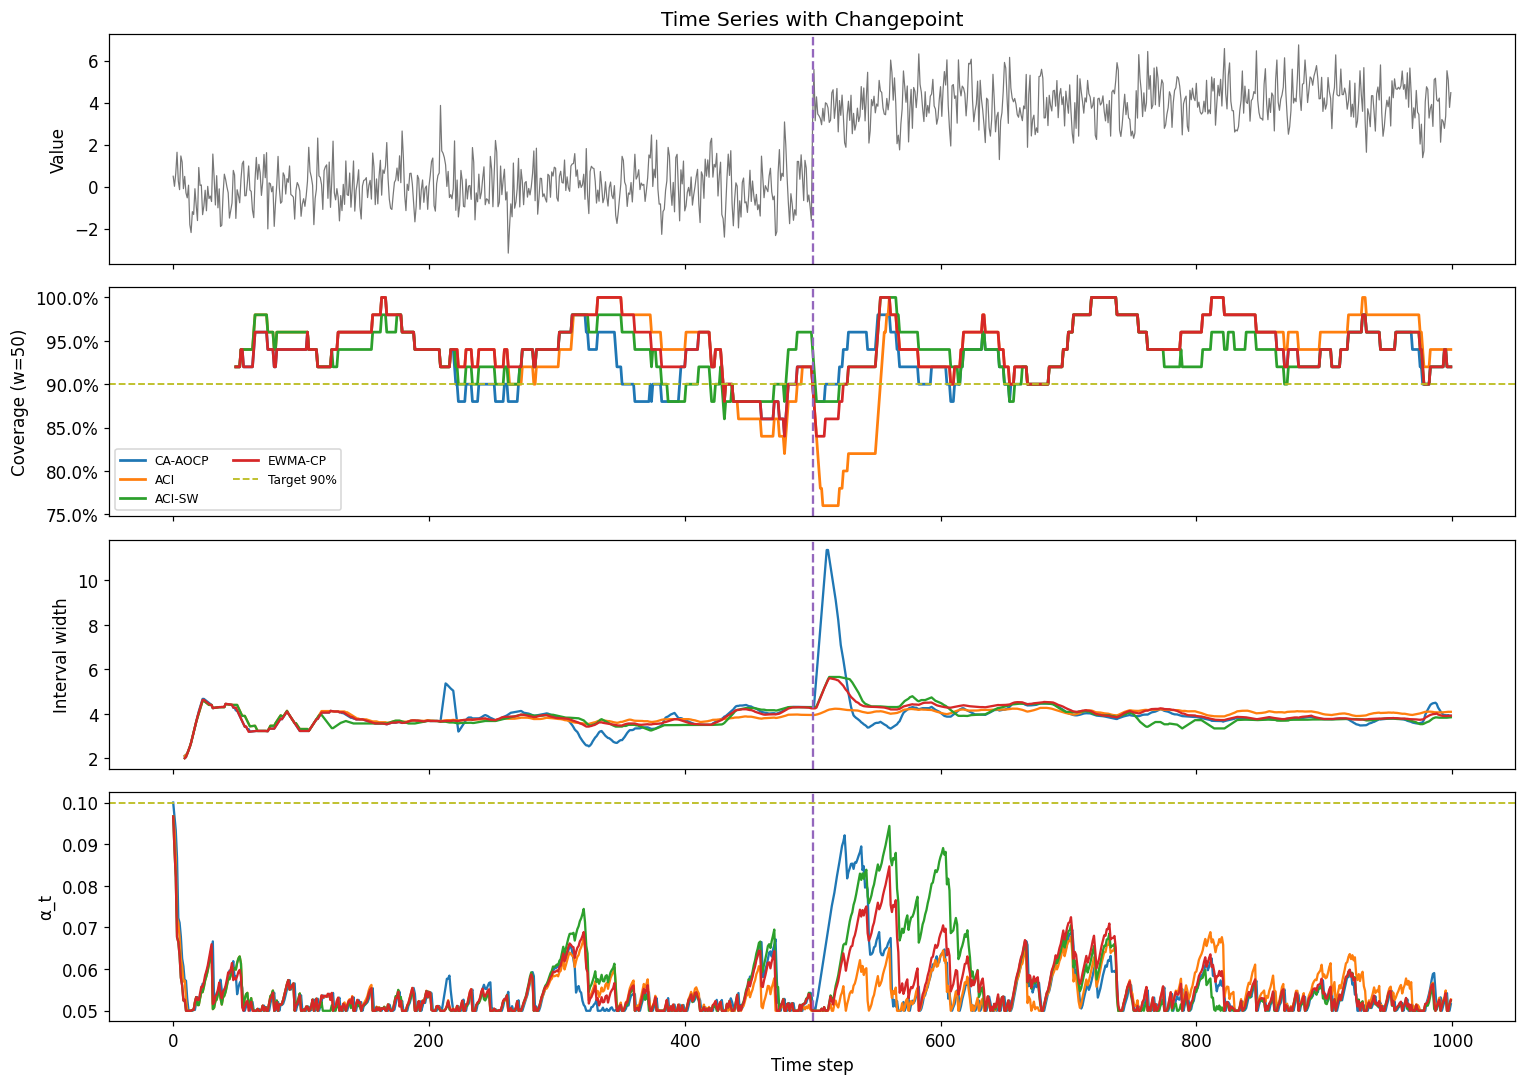

In [29]:
results_all = {
    "CA-AOCP": results_caaocp,
    "ACI"    : aci,
    "ACI-SW" : aci_sw,
    "EWMA-CP": ewma_cp,
}

fig = plot_comparison(ys, results_all, alpha=ALPHA, tau=TAU, window=50)
plt.show()

### Post-Changepoint Coverage Recovery

Zooming into the region immediately after τ = 500 to show the speed of
recovery — the key exponential-vs-linear separation of Theorem 3.

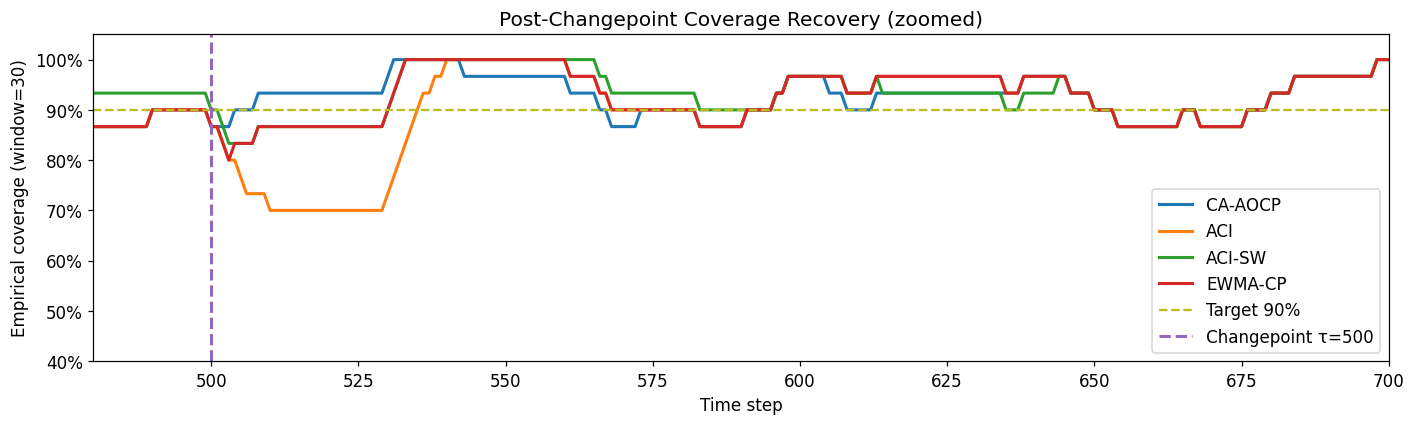

In [13]:
fig, ax = plt.subplots(figsize=(13, 4))
WINDOW = 30
COLORS = {"CA-AOCP":"#1f77b4","ACI":"#ff7f0e","ACI-SW":"#2ca02c","EWMA-CP":"#d62728"}
for name, res in results_all.items():
    cov = np.array(res.coverages if hasattr(res,"coverages") else res.coverage, dtype=float)
    rolling = np.convolve(cov, np.ones(WINDOW)/WINDOW, mode="valid")
    ts = np.arange(WINDOW-1, T)
    ax.plot(ts, rolling, label=name, color=COLORS[name], lw=2.0)

ax.axhline(1-ALPHA, color="#bcbd22", ls="--", lw=1.5, label=f"Target {int((1-ALPHA)*100)}%")
ax.axvline(TAU, color="#9467bd", lw=2, ls="--", label="Changepoint τ=500")
ax.set_xlim(TAU - 20, TAU + 200)
ax.set_ylim(0.4, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlabel("Time step")
ax.set_ylabel(f"Empirical coverage (window={WINDOW})")
ax.set_title("Post-Changepoint Coverage Recovery (zoomed)")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Summary Metrics

- **Coverage**: empirical fraction of covered labels (target: 0.900)  
- **Cov. Gap**: |coverage − target|  
- **Mean Width**: average interval width (sharpness; lower is better)  
- **Winkler**: width + penalty for non-coverage (lower is better)

In [30]:
tbl = summary_table(results_all, ys, alpha=ALPHA)
print(tbl.to_string())

        Coverage Target Cov. Gap Mean Width Winkler
Method                                             
CA-AOCP    0.933  0.900   0.0330      3.944   4.592
ACI        0.938  0.900   0.0380      3.920   4.563
ACI-SW     0.934  0.900   0.0340      3.880   4.537
EWMA-CP    0.939  0.900   0.0390      3.940   4.552


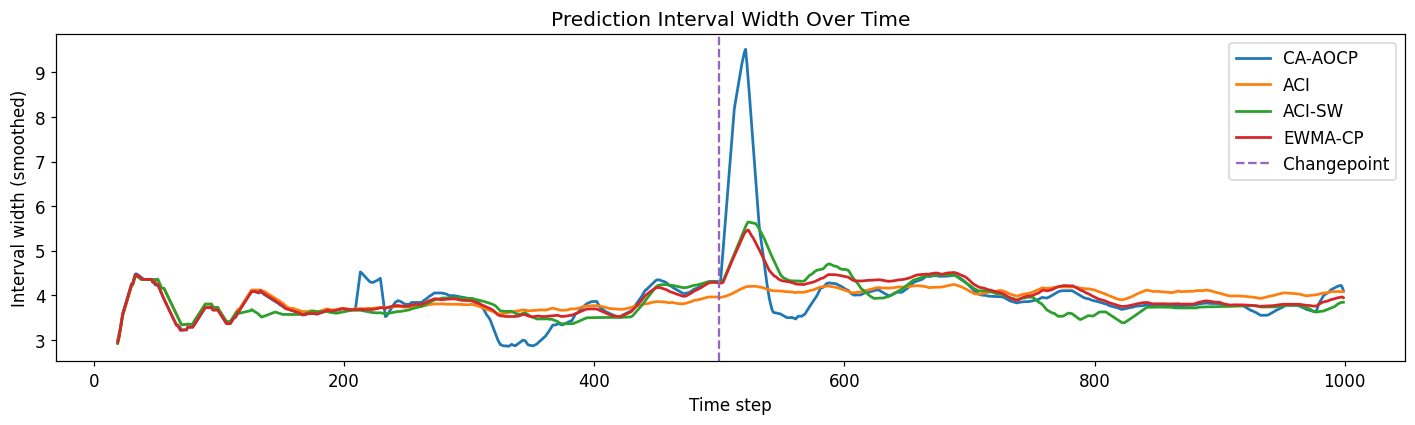

In [15]:
fig, ax = plt.subplots(figsize=(13, 4))
for name, res in results_all.items():
    lows  = np.array(res.lowers  if hasattr(res,"lowers")  else res.lower_bounds)
    highs = np.array(res.uppers  if hasattr(res,"uppers")  else res.upper_bounds)
    widths = highs - lows
    sm = np.convolve(widths, np.ones(20)/20, mode="valid")
    ax.plot(np.arange(19, T), sm, label=name, color=COLORS[name], lw=1.8)
ax.axvline(TAU, color="#9467bd", lw=1.5, ls="--", label="Changepoint")
ax.set_xlabel("Time step")
ax.set_ylabel("Interval width (smoothed)")
ax.set_title("Prediction Interval Width Over Time")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Parameter Sensitivity: Hazard h

We sweep the BOCPD hazard parameter h ∈ {0.001, 0.005, 0.01, 0.02, 0.05}
and report long-run coverage and mean width. This illustrates the
robustness discussed in Appendix B.5.

In [16]:
hazards = [0.001, 0.005, 0.01, 0.02, 0.05]
rows = []
for h in hazards:
    m = CAAOCP(
        alpha=ALPHA, eta=0.02, decay=0.01, temperature=0.5,
        hazard=h, max_run_length=400,
        predictor=make_predictor(), init_radius=1.0,
    )
    r = m.run(ys)
    lows  = r.lower_bounds
    highs = r.upper_bounds
    rows.append({
        "hazard h"   : h,
        "Coverage"   : f"{r.long_run_coverage():.3f}",
        "Mean Width" : f"{(highs - lows).mean():.3f}",
        "Cov. Gap"   : f"{abs(r.long_run_coverage() - (1-ALPHA)):.4f}",
    })
sens_df = pd.DataFrame(rows).set_index("hazard h")
print(sens_df.to_string())

         Coverage Mean Width Cov. Gap
hazard h                             
0.001       0.935      3.964   0.0350
0.005       0.934      3.951   0.0340
0.010       0.933      3.952   0.0330
0.020       0.933      3.962   0.0330
0.050       0.934      3.969   0.0340


In [17]:
etas = [0.005, 0.01, 0.02, 0.05, 0.1]
rows = []
for e in etas:
    m = CAAOCP(
        alpha=ALPHA, eta=e, decay=0.01, temperature=0.5,
        hazard=0.005, max_run_length=400,
        predictor=make_predictor(), init_radius=1.0,
    )
    r = m.run(ys)
    lows  = r.lower_bounds
    highs = r.upper_bounds
    rows.append({
        "eta"        : e,
        "Coverage"   : f"{r.long_run_coverage():.3f}",
        "Mean Width" : f"{(highs - lows).mean():.3f}",
        "Cov. Gap"   : f"{abs(r.long_run_coverage() - (1-ALPHA)):.4f}",
    })
sens_eta = pd.DataFrame(rows).set_index("eta")
print(sens_eta.to_string())

      Coverage Mean Width Cov. Gap
eta                               
0.005    0.936      3.979   0.0360
0.010    0.934      3.979   0.0340
0.020    0.934      3.951   0.0340
0.050    0.930      3.881   0.0300
0.100    0.927      3.807   0.0270


## Bonus: Conformity Score Distribution Before and After Changepoint

This confirms that the changepoint is visible in the conformity score
sequence — the input to BOCPD — and explains why BOCPD can detect it.

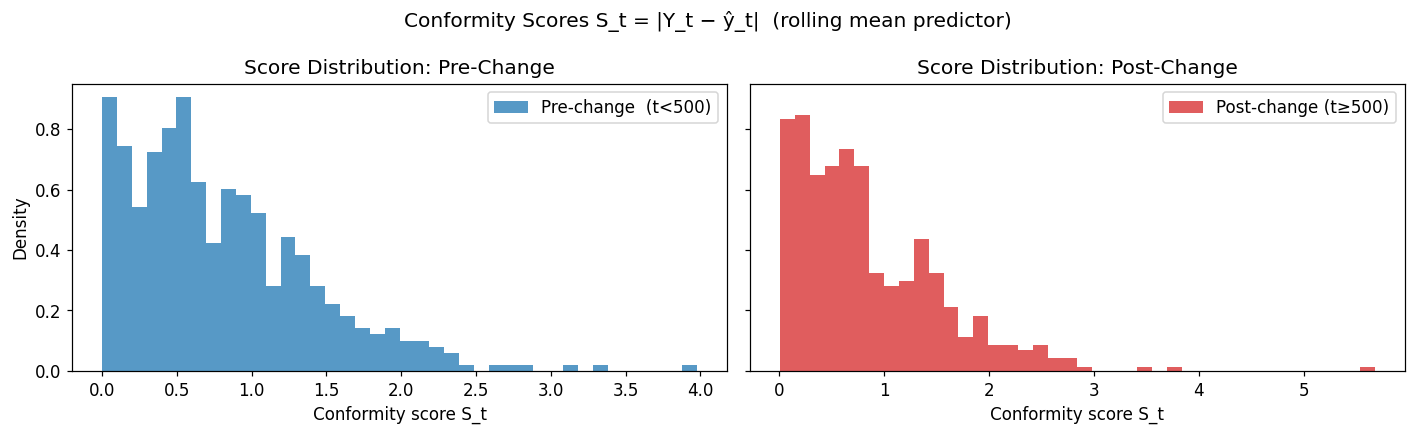

Pre-change  score: mean=0.800  std=0.613
Post-change score: mean=0.845  std=0.696


In [18]:
scores = results_caaocp.scores

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
axes[0].hist(scores[:TAU],  bins=40, color="#1f77b4", alpha=0.75,
             label=f"Pre-change  (t<{TAU})", density=True)
axes[0].set_xlabel("Conformity score S_t")
axes[0].set_ylabel("Density")
axes[0].set_title("Score Distribution: Pre-Change")
axes[0].legend()

axes[1].hist(scores[TAU:], bins=40, color="#d62728", alpha=0.75,
             label=f"Post-change (t≥{TAU})", density=True)
axes[1].set_xlabel("Conformity score S_t")
axes[1].set_title("Score Distribution: Post-Change")
axes[1].legend()

fig.suptitle("Conformity Scores S_t = |Y_t − ŷ_t|  (rolling mean predictor)")
plt.tight_layout()
plt.show()

print(f"Pre-change  score: mean={np.mean(scores[:TAU]):.3f}  std={np.std(scores[:TAU]):.3f}")
print(f"Post-change score: mean={np.mean(scores[TAU:]):.3f}  std={np.std(scores[TAU:]):.3f}")